# Twin-Spread — a quantitative teardown 🔬
### GGR (1999) minimum-distance pairs · formation · the 2σ trade · decay · neutrality · costs

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decay: Confirmed](https://img.shields.io/badge/Decay-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* Thesis: the **parameter-free** GGR rule, run honestly on a liquid basket, has **no convergence edge** in the modern era — negative before costs, market-neutral (β≈0), short-gamma (win-rate > 50%, mean ≤ 0).

> ⚠️ **Not investment advice.** Executed on the **synthetic universe** (true twins), where the rule works — validating the machinery end-to-end; the real verdict is quoted from [`../docs/results.md`](../docs/results.md) (`examples/verify_real.py`), the literature mapped in [`../docs/references.md`](../docs/references.md). Fixed seeds, no network.
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (pairs_trading/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from pairs_trading import data, pairs, backtest, robustness

# Offline synthetic universe: true cointegrated twins hidden among noise names. This is
# where the rule SHOULD work — so it validates the machinery. The real verdict (a liquid
# ~170-name basket where it does NOT work) is in ../docs/results.md via verify_real.py.
panel, frames, true_pairs = data.synthetic_universe(seed=0)
print(f"{panel.shape[1]} names, {panel.shape[0]} sessions, {len(true_pairs)} true twins baked in")


40 names, 1500 sessions, 8 true twins baked in


## 1 · The claim, as a testable hypothesis

H₁: the top-N minimum-SSD pairs earn a positive **committed-capital** convergence return, annualised Sharpe CI above 0, market β≈0.
H₁′ (sharp): it survives bid-ask costs *and* the post-2002 regime.
H₀: minimum-distance ≠ cointegration; convergence is a coin flip whose negative skew (non-reconverging breaks) pulls the mean to ≤ 0.

In [2]:
formation = panel.iloc[:252]
selected = pairs.select_pairs(formation, top_n=len(true_pairs))
print('selection recall on true twins:', robustness.selection_recall(selected, true_pairs))
pd.DataFrame([(p.a, p.b, round(p.ssd,4), round(p.sigma,4)) for p in selected],
             columns=['a','b','ssd','sigma'])

selection recall on true twins: 1.0


,a,b,ssd,sigma
0,TW01A,TW01B,0.0846,0.0157
1,TW05A,TW05B,0.1104,0.0209
2,TW07A,TW07B,0.2451,0.0203
3,TW06A,TW06B,0.2495,0.0274
4,TW04A,TW04B,0.2693,0.0241
5,TW02A,TW02B,0.2871,0.0317
6,TW00A,TW00B,0.3402,0.0367
7,TW03A,TW03B,0.4052,0.0392


## 3–4 · The trade, and committed-capital P&L

Open at 2σ, close on the zero-crossing, **wait=1** (act on the triggering close, earn from the next session — no look-ahead). Committed capital averages all N pairs daily (idle pairs contribute 0).

{'n_days': 1134, 'n_trades': 103, 'committed_monthly_net': 0.0086, 'committed_monthly_gross': 0.0092, 'employed_monthly_net': 0.0174, 'sharpe_net': 1.9217, 'ann_return_net': 0.1083, 'max_drawdown': -0.0646, 'deployed_frac': 0.4923, 'mean_trade_gross': 0.0385, 'mean_trade_net': 0.0359, 'win_rate_net': 0.835, 'median_days_held': 31.0}


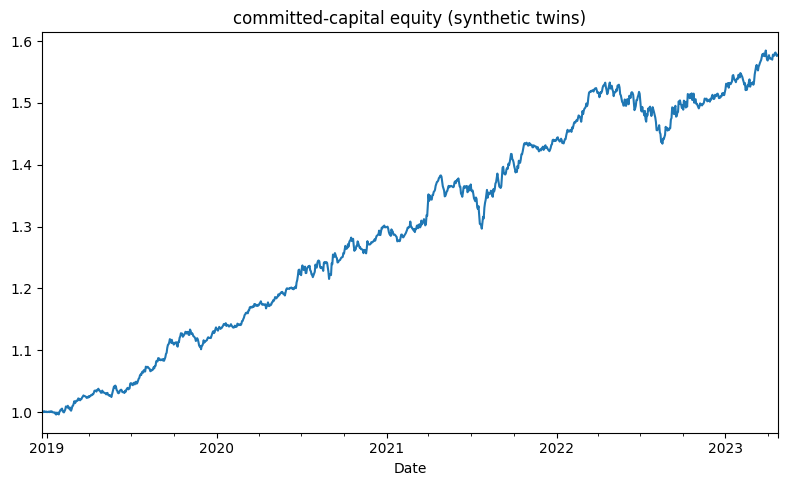

In [3]:
res = backtest.run(panel, top_n=8, form_len=252, trade_len=126, wait=1)
print({k:(round(v,4) if isinstance(v,float) else v) for k,v in res.stats.items()})
res.equity.plot(title='committed-capital equity (synthetic twins)'); plt.show()

## 4 · Decay — the same rule, year by year

On the synthetic there's no decay by construction (stationary twins). On **real** data this is the headline: positive years cluster 1983–2004, the modern era is mostly red. See [`../docs/results.md`](../docs/results.md).

In [4]:
robustness.decay_by_year(panel, top_n=8).round(4)

,monthly_net,sharpe,n_days
year,,,
2018,0.0020,1.5945,8
2019,0.0103,3.1251,261
2020,0.0108,2.5485,262
2021,0.0084,1.6135,261
2022,0.0044,0.8744,260
2023,0.0102,2.5380,82


## 4 · Market-neutrality and the bootstrap Sharpe

A dollar-neutral book should show β≈0 — so the return (good or bad) is the convergence rule itself, not disguised market exposure. The bootstrap CI is the desk-standard read on 'could the Sharpe be zero?'

In [5]:
mkt = data.market_return(panel)
r4 = lambda d: {k: (round(v, 4) if isinstance(v, float) else v) for k, v in d.items()}
print('neutrality:', r4(robustness.market_neutrality(res.daily, mkt)))
print('bootstrap :', r4(robustness.bootstrap_sharpe(res.daily, n_boot=2000)))

neutrality: {'alpha_daily_bps': 4.2389, 'alpha_ann_pct': 11.2708, 'beta': -0.0597, 'r_squared': 0.003}


bootstrap : {'sharpe': 1.9217, 'ci_low': 1.0411, 'ci_high': 2.8044, 'frac_negative': 0.0, 'n_obs': 1134, 'n_boot': 2000, 'n_boot_valid': 2000, 'block_size': 10, 'method': 'cbb'}


> On **real** data these read: β = 0.04, R² = 0.00 (cleanly neutral), and a modern bootstrap Sharpe CI of **[−0.82, −0.07]** — *entirely below zero*, 99% of resamples negative. The full-sample CI [−0.35, +0.09] straddles zero (the thin early universe dilutes it).

## 5 · The verdict, with the numbers

**Signal `NONE`** (real gross −0.47%/mo, CI below 0, negative at zero cost). **Tradability `MIRAGE`** (net −0.53%/mo, −85% DD, β≈0, capacity ample so liquidity isn't the constraint — the missing edge is). **Decay `CONFIRMED`** (best years 1983–2004; modern era red; green only in dislocations — 2008 +0.9%/mo Sharpe 1.30).

## 6 · Could you trade it — costs and the short-gamma tail

The cost sweep on the synthetic is monotone (wider spread never helps); on real data it starts *already negative at 0 bp* — the tell that there's no edge underneath. The win-rate-vs-mean gap is the short-gamma signature: bounded gains to the cross, unbounded loss when a pair breaks.

In [6]:
sweep = backtest.cost_sweep(panel, top_n=8, half_spread_grid=(0,2,5,10,20,40))
display(sweep.round(4))
dvol = data.dollar_volume_panel(frames)
edge = max(res.stats['mean_trade_net'], 1e-9)*1e4
print('capacity (per leg) at a nominal 20bp edge:',
      {k:(round(v,1) if isinstance(v,float) else v) for k,v in robustness.capacity(dvol, res.trades, edge_bps=max(edge,20)).items()})

,roundtrip_bps,committed_monthly_net,sharpe_net,mean_trade_net,n_trades
half_spread_bps,,,,,
0,6.0000,0.0090,2.0295,0.0379,103
2,14.0000,0.0089,1.9865,0.0371,103
5,26.0000,0.0086,1.9217,0.0359,103
10,46.0000,0.0081,1.8133,0.0339,103
20,86.0000,0.0071,1.5951,0.0299,103
40,166.0000,0.0052,1.1566,0.0219,103


capacity (per leg) at a nominal 20bp edge: {'median_adv_usd': 111177570.2, 'capacity_usd_per_leg': 14354805.4, 'edge_bps': 359.3}


## 7 · Going further — the fixes, worked

We ran the three standard rescues, each one change to the rule. On the synthetic (true twins) the stop-loss should cut the drawdown while keeping the edge; the cells below show it. On **real** data ([`../docs/extensions.md`](../docs/extensions.md)) none clears the bar — stop-loss −0.09%/mo (DD −85%→−30%), cointegration gate −0.49%/mo (no help), both −0.13%/mo. The stop does all the work, and only stanches the bleed; the gate's in-sample stationarity doesn't forecast convergence.

In [7]:
import pandas as pd
rows = []
for name, kw in [('baseline', {}), ('+stop 10%', dict(stop_loss=0.10)),
                 ('+coint gate', dict(cointegration=True)),
                 ('+both', dict(stop_loss=0.10, cointegration=True))]:
    r = backtest.run(panel, top_n=8, **kw).stats
    rows.append({'variant': name, 'monthly_net': r['committed_monthly_net'],
                 'sharpe': r['sharpe_net'], 'max_dd': r['max_drawdown']})
display(pd.DataFrame(rows).set_index('variant').round(4))
print('stop-loss scan (synthetic):')
display(robustness.stop_loss_scan(panel, top_n=8).round(4))

,monthly_net,sharpe,max_dd
variant,,,
baseline,0.0086,1.9217,-0.0646
+stop 10%,0.0088,2.4415,-0.0342
+coint gate,0.0039,0.4412,-0.1626
+both,0.0064,0.9838,-0.0908


stop-loss scan (synthetic):


,committed_monthly_net,sharpe_net,max_drawdown,win_rate_net,n_trades
variant,,,,,
none,0.0086,1.9217,-0.0646,0.8350,103
5%,0.0073,2.3752,-0.0333,0.7670,103
10%,0.0088,2.4415,-0.0342,0.8155,103
20%,0.0077,1.9470,-0.0526,0.8155,103


Still open: a **real S&P 1500 cache** (point `data.load_universe` at thousands of names), **total-return** prices (off the split-only bias), and the **crisis-only book** (is a conditional 2008/2020 pairs hedge real?).

Engine: [`../../../quantlab/`](../../../quantlab/). Method: [`METHODOLOGY.md`](../../../METHODOLOGY.md).